<a href="https://colab.research.google.com/github/anamikaponnu/Heart-Disease-Prediction/blob/main/Feature_engineering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import mutual_info_classif, chi2
from sklearn.feature_selection import SelectKBest

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import accuracy_score, classification_report

 Data Collection

In [9]:
import pandas as pd

# Load dataset
df = pd.read_csv('/content/Heart_disease_cleveland_new.csv')

# Basic info
print("First 5 rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nStatistical Summary:")
print(df.describe())

First 5 rows:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   0       145   233    1        2      150      0      2.3      2   
1   67    1   3       160   286    0        2      108      1      1.5      1   
2   67    1   3       120   229    0        2      129      1      2.6      1   
3   37    1   2       130   250    0        0      187      0      3.5      2   
4   41    0   1       130   204    0        2      172      0      1.4      0   

   ca  thal  target  
0   0     2       0  
1   3     1       1  
2   2     3       1  
3   0     1       0  
4   0     1       0  

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol    

Data Preprocessing & Cleaning

In [10]:
# Handle missing values
df.replace("?", pd.NA, inplace=True)
df.dropna(inplace=True)

# Convert all columns to numeric (if needed)
df = df.apply(pd.to_numeric)

# Split features & target
X = df.drop('target', axis=1)
y = df['target']

# Feature Scaling
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Exploratory Data Analysis (EDA)

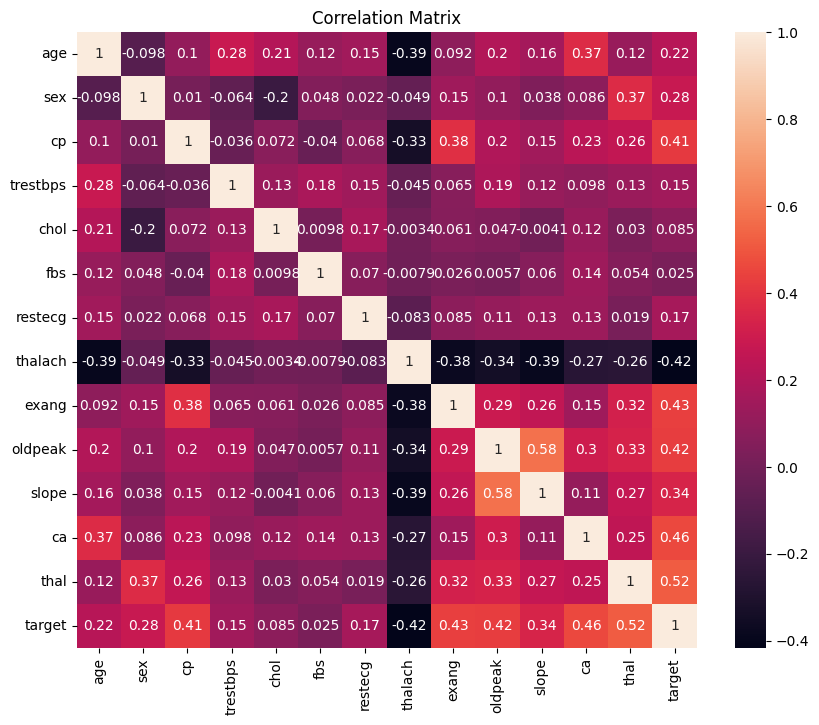

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

Feature Engineering

In [12]:
from sklearn.feature_selection import mutual_info_classif, chi2, SelectKBest

# Mutual Information
mi_scores = mutual_info_classif(X_scaled, y)

mi_df = pd.DataFrame({
    'Feature': X.columns,
    'MI Score': mi_scores
}).sort_values(by='MI Score', ascending=False)

print("Mutual Information:\n", mi_df)

# Chi-Square
chi_selector = SelectKBest(score_func=chi2, k=8)
X_chi = chi_selector.fit_transform(abs(X_scaled), y)

chi_scores = chi_selector.scores_
chi_df = pd.DataFrame({
    'Feature': X.columns,
    'Chi Score': chi_scores
}).sort_values(by='Chi Score', ascending=False)

print("\nChi-Square:\n", chi_df)

Mutual Information:
      Feature  MI Score
12      thal  0.143803
2         cp  0.134339
11        ca  0.127372
7    thalach  0.089743
8      exang  0.087546
4       chol  0.072566
9    oldpeak  0.070251
10     slope  0.056034
3   trestbps  0.042618
6    restecg  0.027858
1        sex  0.026870
0        age  0.000000
5        fbs  0.000000

Chi-Square:
      Feature  Chi Score
8      exang   7.235528
9    oldpeak   5.649626
11        ca   5.596589
1        sex   3.220230
0        age   1.553033
12      thal   1.335979
7    thalach   0.779052
3   trestbps   0.749685
2         cp   0.536541
10     slope   0.470242
5        fbs   0.134371
6    restecg   0.011038
4       chol   0.003205
